# NELL-995+ Analysis

In [2]:
from pickle import load
from glob import glob
from tqdm import tqdm
from math import log, ceil
import plotly.graph_objects as go

In [3]:
destination_folder=f"./NELL-995+"

In [4]:
destination_folder=f"{destination_folder}{'/' if not destination_folder[-1] in ['\\', '/'] else ''}"
dest_txt_folder=destination_folder
dest_pkl_folder=f"{destination_folder}pickle/"

In [5]:
ent2id = None

with open(f"{dest_pkl_folder}ent2id.pkl", "rb") as handle:
    ent2id = load(handle)

id2ent = {v: k for k, v in ent2id.items()}

rel2id = None

with open(f"{dest_pkl_folder}rel2id.pkl", "rb") as handle:
    rel2id = load(handle)

id2rel = {v: k for k, v in rel2id.items()}

class2id = None

with open(f"{dest_pkl_folder}class2id.pkl", "rb") as handle:
    class2id = load(handle)

id2class = {v: k for k, v in class2id.items()}

instype_all = None

with open(f"{dest_pkl_folder}inst_type_all.pkl", "rb") as handle:
    instype_all = load(handle)

rid2domid = None

with open(f"{dest_pkl_folder}rid2domid.pkl", "rb") as handle:
    rid2domid = load(handle)

rid2domid={k: list(v)[0] for k, v in rid2domid.items()}

rid2rangeid = None

with open(f"{dest_pkl_folder}rid2rangeid.pkl", "rb") as handle:
    rid2rangeid = load(handle)

rid2rangeid={k: list(v)[0] for k, v in rid2rangeid.items()}

observed_heads_original_kg = None

with open(f"{dest_pkl_folder}observed_heads_original_kg.pkl", "rb") as handle:
    observed_heads_original_kg = load(handle)

classid2entid = None

with open(f"{dest_pkl_folder}classid2entid.pkl", "rb") as handle:
    class2id2ent2id = load(handle)

In [6]:
len(ent2id), len(instype_all), len(class2id.keys())

(75492, 75492, 267)

In [7]:
total=len(rel2id.values())

signed=[
    p
    for p in rel2id.values()
    if p in rid2domid.keys() 
    and p in rid2rangeid.keys()
]

domain_no_range = [
    p
    for p in rel2id.values()
    if p in rid2domid.keys() 
    and not p in rid2rangeid.keys()
]

range_no_domain = [
    p
    for p in rel2id.values()
    if not p in rid2domid.keys() 
    and p in rid2rangeid.keys()
]

not_signed = [
    p
    for p in rel2id.values()
    if not p in rid2domid.keys() 
    and not p in rid2rangeid.keys()
]

print("Domain/range information, counted in number of different predicates:\n")

print("Total:\t\t\t", total)
print("Totally signed:\t\t", len(signed), int(10000*len(signed)/total)/100)
print("Domain-only signed:\t", len(domain_no_range), int(10000*len(domain_no_range)/total)/100)
print("Range-only signed:\t", len(range_no_domain), int(10000*len(range_no_domain)/total/100))
print("Unsigned:\t\t", len(not_signed), int(10000*len(not_signed)/total)/100)

Domain/range information, counted in number of different predicates:

Total:			 200
Totally signed:		 187 93.5
Domain-only signed:	 3 1.5
Range-only signed:	 3 1
Unsigned:		 7 3.5


In [8]:
def flow(
    split_name,
    total_count,
    signed_count,
    not_signed_count,
    not_instanciated_signatures_for_signed_count,
    domain_no_range_count,
    range_no_domain_count,
    not_instanciated_domains_for_domained_count,
    not_instanciated_ranges_for_ranged_count,
    x_divider=4,
    y_divider=10,
    x_offset=0,
    y_offset=0.65,
    skip_nodes=[]
):

    nodes = {
        'Total': {'x': 0, 'y': 0},
        'Full sign': {'x': 1, 'y': 4},
        'Incomplete sign': {'x': 1, 'y': -3},
        'Half sign': {'x': 2, 'y': -4},
        'Unsigned': {'x': 2, 'y': -9},
        'Domain-only': {'x': 3, 'y': 1},
        'Range-only': {'x': 3, 'y': -7},
        'No domain inst': {'x': 4, 'y': 1},
        'No range inst': {'x': 4, 'y': -8},
        'Domain inst': {'x': 4, 'y': 4},
        'Range inst': {'x': 4, 'y': -5},
        'No sign instance': {'x': 2, 'y': 5},
        'Sign instance': {'x': 2, 'y': 3}
    }
    
    flows=[
        {"from": 'Total', "to": 'Full sign', 'value': signed_count},
        {"from": 'Total', "to": 'Incomplete sign', 'value': total_count - signed_count},
    
        {"from": 'Full sign', "to": 'No sign instance', 'value': not_instanciated_signatures_for_signed_count},
        {"from": 'Full sign', "to": 'Sign instance', 'value': signed_count - not_instanciated_signatures_for_signed_count},
    
        {"from": 'Incomplete sign', "to": 'Unsigned', 'value': not_signed_count},
        {"from": 'Incomplete sign', "to": 'Half sign', 'value': total_count - signed_count - not_signed_count},
    
        {"from": 'Half sign', "to": 'Domain-only', 'value': domain_no_range_count},
        {"from": 'Half sign', "to": 'Range-only', 'value': range_no_domain_count},
    
        {"from": 'Domain-only', "to": 'No domain inst', 'value': domain_no_range_count - not_instanciated_domains_for_domained_count},
        {"from": 'Domain-only', "to": 'Domain inst', 'value': not_instanciated_domains_for_domained_count},
    
        {"from": 'Range-only', "to": 'No range inst', 'value': range_no_domain_count - not_instanciated_ranges_for_ranged_count},
        {"from": 'Range-only', "to": 'Range inst', 'value': not_instanciated_ranges_for_ranged_count}
    ]
    
    null_nodes=[n["to"] for n in flows if n["value"] == 0]
    
    def descendants(name):
        children=[n["to"] for n in flows if n["from"] == name]
        return [name] + [
            item
            for node in children
            for item in descendants(node)
        ]
        
    filtered_nodes = [item for nodes in null_nodes + skip_nodes for item in descendants(nodes)]
    kept_nodes = {node: coordinates for node, coordinates in nodes.items() if not node in filtered_nodes}
    kept_flows = [flow for flow in flows if flow["from"] in kept_nodes.keys() and flow["to"] in kept_nodes.keys()]
    
    node2id={node: i for i, node in enumerate(kept_nodes.keys())}
    
    label=list(kept_nodes.keys())
    x=[kept_nodes[key]["x"] for key in kept_nodes.keys()]
    y=[kept_nodes[key]["y"] for key in kept_nodes.keys()]
    
    x=[item/x_divider+x_offset for item in x]
    y=[item/y_divider+y_offset for item in y]
    
    sources=[node2id[flow["from"]] for flow in kept_flows]
    targets=[node2id[flow["to"]] for flow in kept_flows]
    values=[flow["value"] for flow in kept_flows]
    
    
    fig = go.Figure(
        data=[
            go.Sankey(
                node = dict(
                    pad = 15,
                    thickness = 20,
                    line = dict(color = "black", width = 0.5),
                    label = label,
                    x = x,
                    y = y,
                    color = "blue"
                ),
                link = dict(
                    source = sources,
                    target = targets,
                    value = values
                )
            )
        ]
    )
    
    #fig.update_layout(title_text=f"Domain/range coverage over triples of dataset {destination_folder.split('/')[-2]}", font_size=13)
    fig.show()
    fig.write_image(f"{destination_folder}sankey_diagram_NELL-995+_{split_name}.png", width=1500, height=450)

In [9]:
predicate_count={id: 0 for id in rel2id.values()}

def display_chart(
    splits=["train", "test", "valid"],
    x_divider=4,
    y_divider=10,
    x_offset=0,
    y_offset=0.65,
    skip_nodes=[]
):
    
    predicate_count={id: 0 for id in rel2id.values()}
    
    for split in splits:
        nb_lines=sum(1 for _ in open(f"{dest_txt_folder}{split}2id.txt", "r", encoding="utf-8"))
        with open(f"{dest_txt_folder}{split}2id.txt", "r", encoding='utf-8') as r:
            with tqdm(enumerate(r), total=nb_lines, disable=True) as bar:
                for i, line in bar:
                    p = int(line.strip().split("\t")[1])
                    predicate_count[p] += 1
        
    total_count=sum(predicate_count.values())
    
    signed_count=sum([
        predicate_count[p]
        for p in signed
    ])
    
    domain_no_range_count = sum([
        predicate_count[p]
        for p in domain_no_range
    ])
    
    range_no_domain_count = sum([
        predicate_count[p]
        for p in range_no_domain
    ])
    
    not_signed_count = sum([
        predicate_count[p]
        for p in not_signed
    ])
    
    def percent(number, total, precision=4):
        n=int(number.replace(" ", "")) if isinstance(number, str) else number
        t=int(total.replace(" ", "")) if isinstance(total, str) else total

        if t == 0:
            return "??"
        return int((10**precision)*n/t)/(10**(precision - 2))

    total_count_p = f"{int(total_count):,}".replace(",", " ")
    signed_count_p = f"{int(signed_count):,}".replace(",", " ")
    domain_no_range_count_p = f"{int(domain_no_range_count):,}".replace(",", " ")
    range_no_domain_count_p = f"{int(range_no_domain_count):,}".replace(",", " ")
    not_signed_count_p = f"{int(not_signed_count):,}".replace(",", " ")

    column_margin=8

    column_offset=len(str(total_count_p))
    total_offset=" " * column_margin
    entirely_offset=" " * (column_margin+column_offset-len(str(signed_count_p)))
    domain_offset=" " * (column_margin+column_offset-len(str(domain_no_range_count_p)))
    range_offset=" " * (column_margin+column_offset-len(str(range_no_domain_count_p)))
    not_offset=" " * (column_margin+column_offset-len(str(not_signed_count_p)))
    
    print("\tClass\t\t\t", f"Nb triple        % triple\n")
    print("\tTotal\t\t\t", f"{total_count_p}{total_offset}{percent(total_count, total_count)}%")
    print("\tEntirely signed\t\t", f"{signed_count_p}{entirely_offset}{percent(signed_count, total_count)}%")
    print("\tDomain-only signed\t", f"{domain_no_range_count_p}{domain_offset}{percent(domain_no_range_count, total_count)}%")
    print("\tRange-only signed\t", f"{range_no_domain_count_p}{range_offset}{percent(range_no_domain_count, total_count)}%")
    print("\tNot signed\t\t", f"{not_signed_count_p}{not_offset}{percent(not_signed_count, total_count)}%")

    predicate_domains_instances = {i: len(class2id2ent2id[rid2domid[i]]) for i in rid2domid.keys()}
    
    not_instanciated_domains = [k for k in predicate_domains_instances.keys() if predicate_domains_instances[k] == 0]
    
    not_instanciated_domains_count = sum([predicate_count[p] for p in not_instanciated_domains])
    not_instanciated_domains_for_signed_count = sum([predicate_count[p] for p in not_instanciated_domains if p in signed])
    not_instanciated_domains_for_domained_count = sum([predicate_count[p] for p in not_instanciated_domains if p in domain_no_range])
    predicate_ranges_instances = {i: len(class2id2ent2id[rid2rangeid[i]]) for i in rid2rangeid.keys()}
    
    not_instanciated_ranges = [k for k in predicate_ranges_instances.keys() if predicate_ranges_instances[k] == 0]
    
    not_instanciated_ranges_count = sum([predicate_count[p] for p in not_instanciated_ranges])
    not_instanciated_ranges_for_signed_count = sum([predicate_count[p] for p in not_instanciated_ranges if p in signed])
    not_instanciated_ranges_for_ranged_count = sum([predicate_count[p] for p in not_instanciated_ranges if p in range_no_domain])
    
    print(
        "\nThese domained predicates have no instances:\n",
        "\t" + "\n\t".join([id2rel[p] for p in not_instanciated_domains])
    )
    
    print(
        "\nThese ranged predicates have no instances:\n",
        "\t" + "\n\t".join([id2rel[p] for p in not_instanciated_ranges])
    )
    
    print("\nOverlap between these sets?", len([x for x in not_instanciated_ranges if x in not_instanciated_domains]) > 0)
    
    not_instanciated_signatures_for_signed_count = (not_instanciated_domains_for_signed_count + not_instanciated_ranges_for_signed_count)
    
    print(
        "\nImpact on signed triples: ",
        f"{not_instanciated_signatures_for_signed_count} ({percent(not_instanciated_signatures_for_signed_count, signed_count)}% of fully signed triples)"
    )
    
    print(
        "Impact on domained triples: ",
        f"{not_instanciated_domains_for_domained_count} ({percent(not_instanciated_domains_for_domained_count, domain_no_range_count)}% of domained triples)"
    )
    
    print(
        "Impact on ranged triples: ",
        f"{not_instanciated_ranges_for_ranged_count} ({percent(not_instanciated_ranges_for_ranged_count, range_no_domain_count)}% of ranged triples)"
    )

    flow(
        "_".join(splits),
        total_count,
        signed_count,
        not_signed_count,
        not_instanciated_signatures_for_signed_count,
        domain_no_range_count,
        range_no_domain_count,
        not_instanciated_domains_for_domained_count,
        not_instanciated_ranges_for_ranged_count,
        x_divider=x_divider,
        y_divider=y_divider,
        x_offset=x_offset,
        y_offset=y_offset,
        skip_nodes=skip_nodes
    )


 TRAIN SPLIT 

	Class			 Nb triple        % triple

	Total			 149 678        100.0%
	Entirely signed		 103 255        68.98%
	Domain-only signed	 6 545          4.37%
	Range-only signed	 25 779         17.22%
	Not signed		 14 099         9.41%

These domained predicates have no instances:
 	

These ranged predicates have no instances:
 	

Overlap between these sets? False

Impact on signed triples:  0 (0.0% of fully signed triples)
Impact on domained triples:  0 (0.0% of domained triples)
Impact on ranged triples:  0 (0.0% of ranged triples)


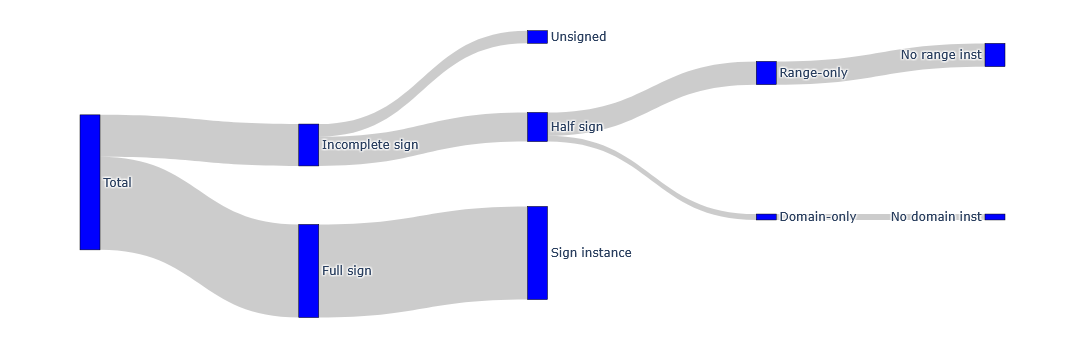

In [24]:
print("\n TRAIN SPLIT \n")

display_chart(splits=["train"], x_divider=4, y_offset=0.55)


 TEST SPLIT 

	Class			 Nb triple        % triple

	Total			 3 992        100.0%
	Entirely signed		 3 992        100.0%
	Domain-only signed	 0            0.0%
	Range-only signed	 0            0.0%
	Not signed		 0            0.0%

These domained predicates have no instances:
 	

These ranged predicates have no instances:
 	

Overlap between these sets? False

Impact on signed triples:  0 (0.0% of fully signed triples)
Impact on domained triples:  0 (??% of domained triples)
Impact on ranged triples:  0 (??% of ranged triples)


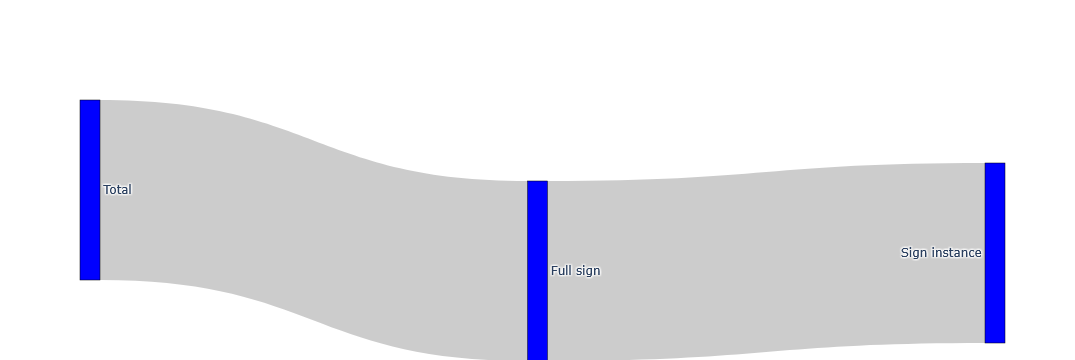

In [11]:
print("\n TEST SPLIT \n")

display_chart(splits=["test"], x_divider=2, y_offset=0.55)


 VALID SPLIT 

	Class			 Nb triple        % triple

	Total			 543        100.0%
	Entirely signed		 543        100.0%
	Domain-only signed	 0          0.0%
	Range-only signed	 0          0.0%
	Not signed		 0          0.0%

These domained predicates have no instances:
 	

These ranged predicates have no instances:
 	

Overlap between these sets? False

Impact on signed triples:  0 (0.0% of fully signed triples)
Impact on domained triples:  0 (??% of domained triples)
Impact on ranged triples:  0 (??% of ranged triples)


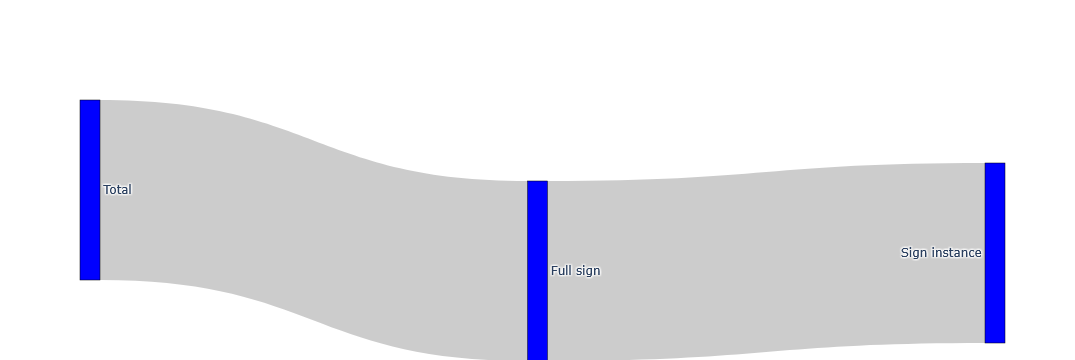

In [12]:
print("\n VALID SPLIT \n")

display_chart(splits=["valid"], x_divider=2, y_offset=0.55)